In [78]:
import pandas as pd

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

In [79]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV

from sklearn.preprocessing import StandardScaler

from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings('ignore')

## Data Quality Assessment

Before analysis and model building, the dataset is checked for missing values and duplicate records.

In [80]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [81]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (2640, 12)

Column Names:
['Year', 'Month', 'Region', 'Model', 'Estimated_Deliveries', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Source_Type', 'Charging_Stations']


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [83]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [84]:
print("Missing Values:\n")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Missing Values:

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicate Rows:
0


### Observation

No missing values or duplicate records were found in the dataset. Therefore, no additional cleaning steps were required before analysis.

### Exploratory Data Analysis (EDA)

EDA is performed to understand patterns, trends, and relationships among Tesla deliveries, production, pricing, battery capacity, and other business variables.

### Year-wise Estimated Deliveries Trend

This analysis examines how Tesla's estimated deliveries have changed over time from 2015 to 2025.

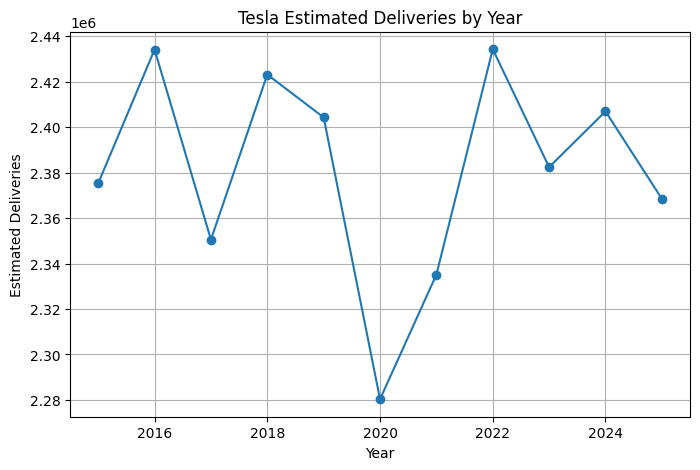

In [85]:
yearly_deliveries = df.groupby('Year')['Estimated_Deliveries'].sum()

plt.figure(figsize=(8,5))
plt.plot(
    yearly_deliveries.index,
    yearly_deliveries.values,
    marker='o'
)

plt.title('Tesla Estimated Deliveries by Year')
plt.xlabel('Year')
plt.ylabel('Estimated Deliveries')
plt.grid(True)

plt.show()

### Observation

Estimated deliveries vary across years, reflecting changes in production capacity and market demand.

### Estimated Deliveries by Region

This analysis compares total estimated deliveries across different regions.

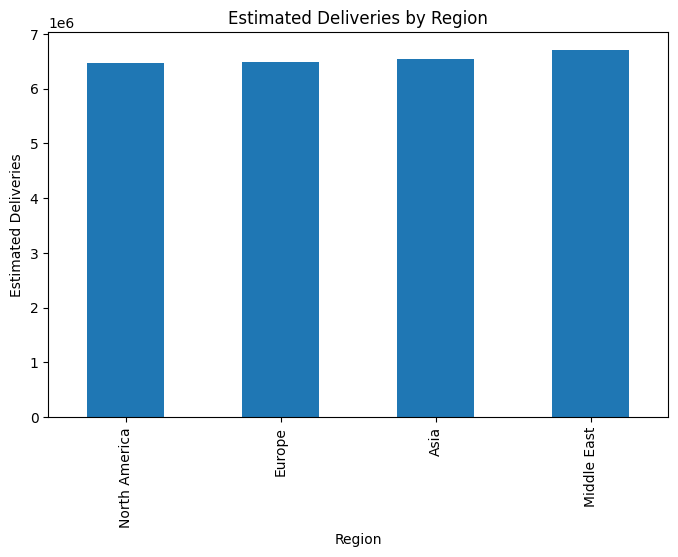

In [86]:
region_deliveries = df.groupby('Region')['Estimated_Deliveries'].sum()

plt.figure(figsize=(8,5))

region_deliveries.sort_values().plot(kind='bar')

plt.title('Estimated Deliveries by Region')
plt.xlabel('Region')
plt.ylabel('Estimated Deliveries')

plt.show()

### Observation

Estimated deliveries vary across regions, indicating differences in market demand and Tesla adoption levels across geographic locations.

### Estimated Deliveries by Model

This analysis identifies the contribution of different Tesla models to total deliveries.

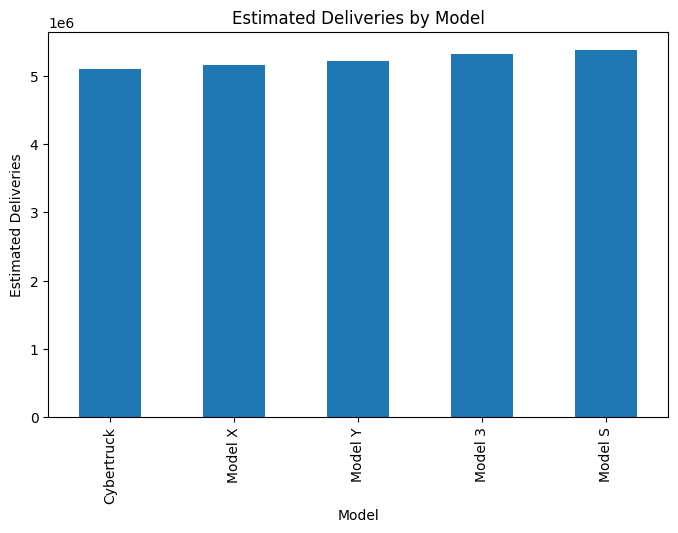

In [87]:
model_deliveries = df.groupby('Model')['Estimated_Deliveries'].sum()

plt.figure(figsize=(8,5))

model_deliveries.sort_values().plot(kind='bar')

plt.title('Estimated Deliveries by Model')
plt.xlabel('Model')
plt.ylabel('Estimated Deliveries')

plt.show()

### Observation

Different Tesla models contribute differently to overall deliveries, reflecting variations in popularity and production volume.

### Correlation Analysis

A correlation heatmap is used to identify relationships among numerical variables.

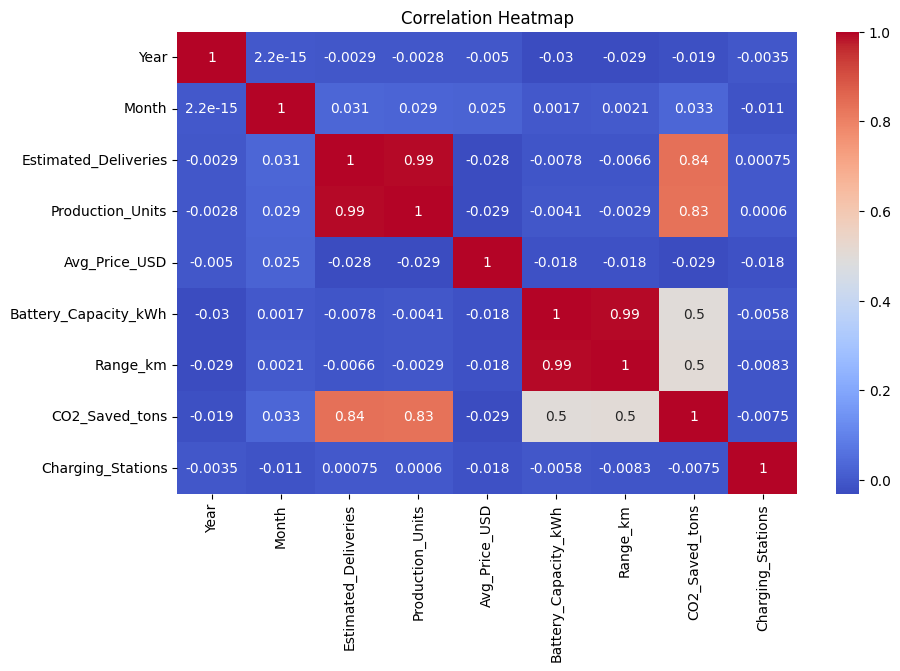

In [88]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.select_dtypes(include=['int64','float64']).corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

### Observation

Estimated Deliveries show a strong positive correlation with Production Units, indicating that production volume has a significant influence on deliveries.

### Feature Engineering

Categorical variables such as Region, Model, and Source_Type are transformed using One-Hot Encoding so that they can be used by machine learning algorithms.

In [89]:
df_encoded = pd.get_dummies(
    df,
    columns=['Region', 'Model', 'Source_Type'],
    drop_first=True
)

df_encoded.head()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations,Region_Europe,Region_Middle East,Region_North America,Model_Model 3,Model_Model S,Model_Model X,Model_Model Y,Source_Type_Interpolated (Month),Source_Type_Official (Quarter)
0,2023,5,17646,17922,92874.27,120,704,1863.42,12207,True,False,False,False,True,False,False,True,False
1,2015,2,3797,4164,62205.65,75,438,249.46,7640,False,False,False,False,False,True,False,False,True
2,2019,1,8411,9189,117887.32,82,480,605.59,14071,False,False,True,False,False,True,False,True,False
3,2021,2,6555,7311,89294.91,120,712,700.07,9333,False,False,True,True,False,False,False,False,True
4,2016,12,12374,13537,114846.78,120,661,1226.88,8722,False,True,False,False,False,False,True,False,False


In [90]:
print("Original Shape:", df.shape)
print("Encoded Shape:", df_encoded.shape)
df_encoded.info()

Original Shape: (2640, 12)
Encoded Shape: (2640, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Year                              2640 non-null   int64  
 1   Month                             2640 non-null   int64  
 2   Estimated_Deliveries              2640 non-null   int64  
 3   Production_Units                  2640 non-null   int64  
 4   Avg_Price_USD                     2640 non-null   float64
 5   Battery_Capacity_kWh              2640 non-null   int64  
 6   Range_km                          2640 non-null   int64  
 7   CO2_Saved_tons                    2640 non-null   float64
 8   Charging_Stations                 2640 non-null   int64  
 9   Region_Europe                     2640 non-null   bool   
 10  Region_Middle East                2640 non-null   bool   
 11  Region_North Ame

### Observation

After applying One-Hot Encoding, the number of features increased from 12 to 18. Categorical variables such as Region, Model, and Source_Type were successfully converted into numerical features, making the dataset suitable for machine learning models.

### Feature Scaling

StandardScaler is applied within the machine learning pipeline to standardize numerical features before model training.

In [91]:
X = df_encoded.drop('Estimated_Deliveries', axis=1)
y = df_encoded['Estimated_Deliveries']
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (2112, 17)
Testing Set: (528, 17)


### Machine Learning Pipeline

A machine learning pipeline is created to combine feature scaling and model training into a single workflow.

In [92]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

pipeline.fit(X_train, y_train)

y_pred_lr = pipeline.predict(X_test)

In [93]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = mean_squared_error(y_test, y_pred_lr) ** 0.5
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 4))

Linear Regression Results
MAE : 309.7
RMSE: 384.03
R² Score: 0.9901


### Observation

The Linear Regression model achieved a high R² score, indicating that the selected features explain a significant portion of the variation in estimated deliveries.


### Cross Validation

Cross Validation is used to evaluate model performance across multiple data splits, providing a more reliable estimate of generalization performance.

In [94]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Cross Validation Scores:")
print(cv_scores)

print("\nAverage R² Score:", round(cv_scores.mean(), 4))

Cross Validation Scores:
[0.99064713 0.99038807 0.98921482 0.99030533 0.99064743]

Average R² Score: 0.9902


### Observation

The cross-validation scores are consistently high across all folds, indicating that the model performs reliably on different subsets of the data.

### Random Forest Regression

A Random Forest Regressor is trained to compare its performance with Linear Regression and determine whether a non-linear model improves prediction accuracy.

In [95]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf) ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE :", round(mae_rf, 2))
print("RMSE:", round(rmse_rf, 2))
print("R² Score:", round(r2_rf, 4))

Random Forest Results
MAE : 321.23
RMSE: 405.35
R² Score: 0.989


In [96]:
comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [round(mae, 2), round(mae_rf, 2)],
    'RMSE': [round(rmse, 2), round(rmse_rf, 2)],
    'R² Score': [round(r2, 4), round(r2_rf, 4)]
})

comparison

,Model,MAE,RMSE,R² Score
0,Linear Regression,309.70,384.03,0.9901
1,Random Forest,321.23,405.35,0.9890


### Observation

Both models achieved strong predictive performance. However, Linear Regression slightly outperformed Random Forest Regression with a higher R² score and lower prediction error.


### Hyperparameter Tuning

Grid Search Cross Validation is used to identify the best hyperparameter combination for the Random Forest Regressor.

In [97]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None]
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest Cross Validation Score:")
print(round(grid_search.best_score_, 4))

Best Parameters:
{'max_depth': None, 'n_estimators': 100}

Best Cross Validation Score:
0.9883


### Observation

Grid Search identified the optimal Random Forest configuration as 100 estimators with no depth restriction. The tuned model achieved a strong cross-validation score, indicating robust predictive performance.

### Time Series Forecasting

Time series forecasting is performed on Tesla estimated deliveries to analyze future delivery trends using the ARIMA model.

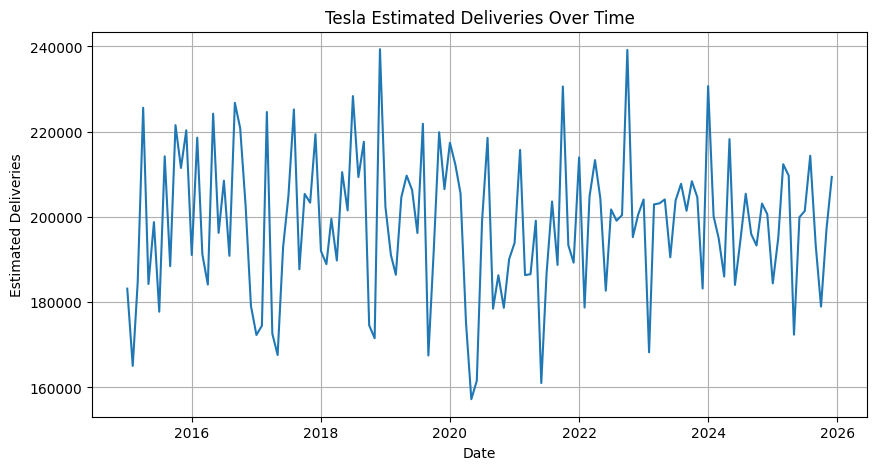

In [98]:
df_ts = df.copy()

df_ts['Date'] = pd.to_datetime(
    df_ts['Year'].astype(str) + '-' +
    df_ts['Month'].astype(str) + '-01'
)

ts = df_ts.groupby('Date')['Estimated_Deliveries'].sum()
plt.figure(figsize=(10,5))

plt.plot(ts)

plt.title('Tesla Estimated Deliveries Over Time')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')

plt.grid(True)

plt.show()

### Observation

The time series plot highlights fluctuations in Tesla deliveries across different periods and serves as the foundation for forecasting future trends.

### ARIMA Model Training and Forecasting

The ARIMA (AutoRegressive Integrated Moving Average) model is used to forecast future Tesla estimated deliveries based on historical delivery trends.

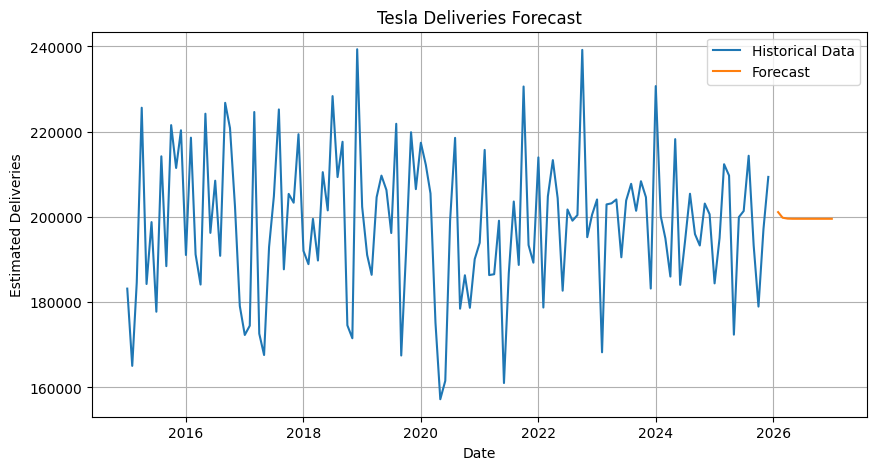

In [99]:
model = ARIMA(ts, order=(1,1,1))

results = model.fit()

forecast = results.forecast(steps=12)

forecast
plt.figure(figsize=(10,5))

plt.plot(ts, label='Historical Data')

future_dates = pd.date_range(
    start=ts.index[-1],
    periods=13,
    freq='M'
)[1:]

plt.plot(
    future_dates,
    forecast,
    label='Forecast'
)

plt.title('Tesla Deliveries Forecast')
plt.xlabel('Date')
plt.ylabel('Estimated Deliveries')

plt.legend()
plt.grid(True)

plt.show()

### Observation

The ARIMA forecast remains relatively stable over the next 12 periods, indicating no strong upward or downward trend in the historical delivery data. This suggests that future estimated deliveries are expected to remain close to recent average levels.

# Conclusion

This project developed an end-to-end machine learning pipeline using Tesla delivery and production data from 2015–2025.

Key tasks completed:
- Data loading and exploration
- Data quality assessment
- Exploratory Data Analysis (EDA)
- Feature engineering using One-Hot Encoding
- Linear Regression modeling
- Random Forest Regression modeling
- Hyperparameter tuning using GridSearchCV
- Time Series Forecasting using ARIMA

Among the evaluated models, Linear Regression achieved the highest R² score (0.9901) and the lowest prediction error, making it the best-performing model for this dataset.
The results demonstrate that Tesla delivery estimates can be effectively predicted using production, pricing, battery specifications, regional information, and charging infrastructure data.